In [25]:
import os
import sys

# Add src folder to system path
src_path = os.path.abspath(os.path.join(os.getcwd(), "src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from preprocessing import scaled_bse_data

# 1. Fetch processed DataFrame
df = scaled_bse_data('RELIANCE.NS')

# 2. Separate Features (X) and Target (y)
X = df.drop(columns=['Target'])
y = df['Target']


split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f" Data loaded! Training rows: {len(X_train)}")

 Data loaded! Training rows: 473


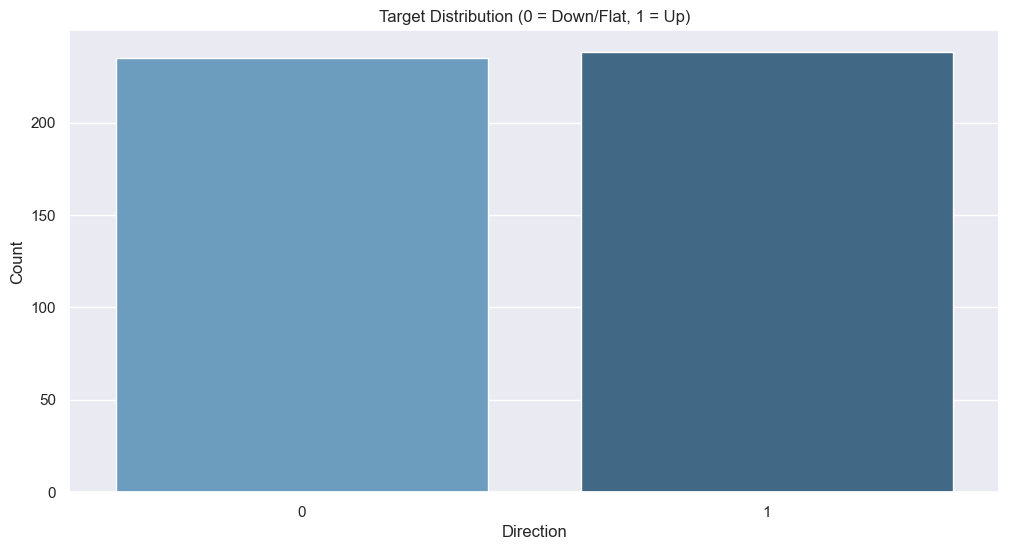

Percentage of Up Days: 50.3%


In [22]:
# Count 0s (Down) vs 1s (Up)
sns.countplot(x=y_train, hue=y_train, palette="Blues_d", legend=False)
plt.title("Target Distribution (0 = Down/Flat, 1 = Up)")
plt.xlabel("Direction")
plt.ylabel("Count")
plt.show()

print(f"Percentage of Up Days: {y_train.mean():.1%}")

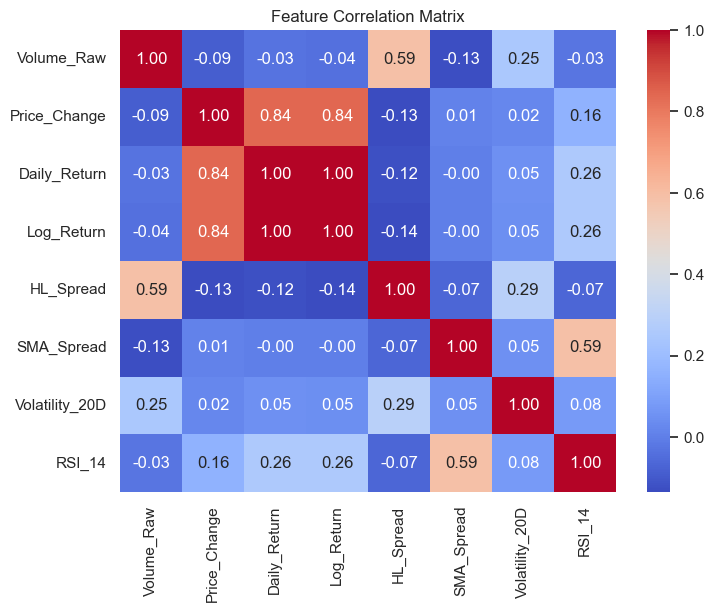

In [23]:
plt.figure(figsize=(8, 6))
sns.heatmap(X_train.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

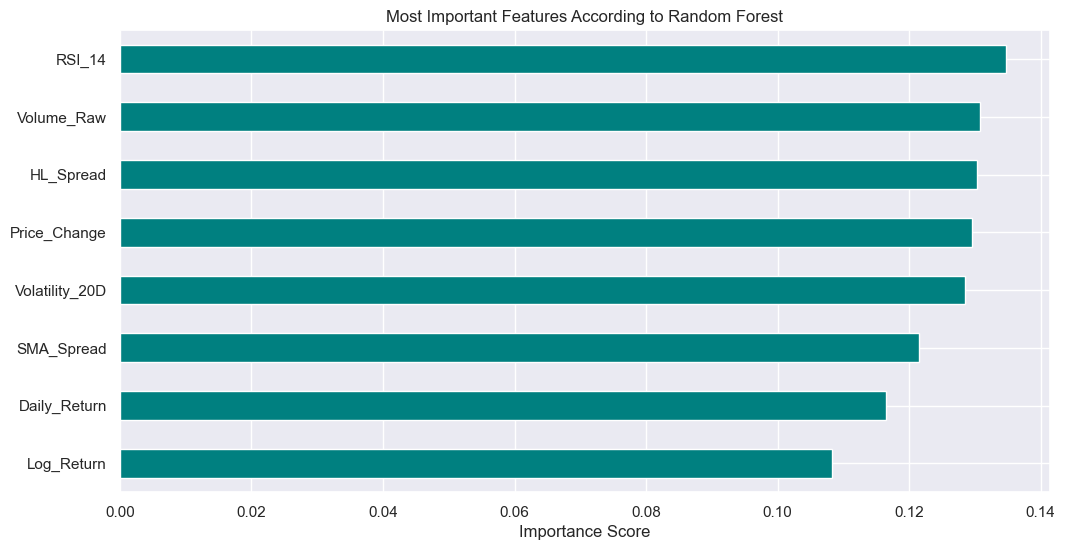

In [24]:
from sklearn.ensemble import RandomForestClassifier

# Train baseline model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Plot feature importance
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance.sort_values().plot(kind="barh", color="teal")

plt.title("Most Important Features According to Random Forest")
plt.xlabel("Importance Score")
plt.show()